# Notebook 06: 한국어 Tiny GPT

이 노트북은 ECO4126 Tiny GPT 프로젝트의 실행 가능한 요약이다. Tiny Shakespeare나 저작권 소설을 사용하지 않고, 직접 작성한 한국어 금융/인공지능 말뭉치로 문자 단위 GPT를 학습한다.

## 학습 진행

1. **Bigram Language Model**: 현재 문자 하나만 보고 다음 문자를 예측한다.
2. **Embedding + MLP character model**: 여러 문자 문맥을 임베딩하고 MLP로 다음 문자를 예측한다.
3. **GPT-style sequence dataset**: `block_size` 길이의 `x`와 한 칸 이동한 `y`를 만든다.
4. **Single-head causal masked self-attention**: 각 위치가 과거 위치만 보도록 causal mask를 적용한다.
5. **Multi-head Tiny GPT**: 여러 head, FFN, residual, LayerNorm, dropout, stacked Transformer block을 사용한다.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.tokenizer import CharTokenizer, load_text
from src.dataset import CharSequenceDataset, split_ids
from src.model import TinyGPT

text = load_text(str(ROOT / 'data/korean_finance_corpus.txt'))
tokenizer = CharTokenizer(text)
len(text), tokenizer.vocab_size

(2711, 370)

## vocabulary, stoi, itos

vocabulary는 말뭉치에 등장하는 모든 고유 문자이다. `stoi`는 문자를 정수 id로 바꾸고, `itos`는 정수 id를 다시 문자로 바꾼다. 문자 단위 한국어 토크나이저는 공백과 문장부호도 문자 토큰으로 포함한다.

In [2]:
sample = '인공지능과 금융'
ids = tokenizer.encode(sample)
ids, tokenizer.decode(ids), list(tokenizer.stoi.items())[:10]

([267, 61, 295, 93, 62, 1, 73, 258],
 '인공지능과 금융',
 [('\n', 0),
  (' ', 1),
  (',', 2),
  ('-', 3),
  ('.', 4),
  ('G', 5),
  ('K', 6),
  ('L', 7),
  ('M', 8),
  ('N', 9)])

## block_size와 x/y shifting

`block_size`는 모델이 한 번에 보는 최대 문맥 길이이다. 데이터셋은 `block_size + 1`개 토큰을 가져와 앞 `block_size`개를 입력 `x`, 뒤 `block_size`개를 목표 `y`로 만든다. 따라서 `y`는 `x`보다 한 칸 앞선 다음 문자 정답이다.

In [3]:
block_size = 64
ids_all = tokenizer.encode(text)
train_ids, val_ids = split_ids(ids_all)
ds = CharSequenceDataset(train_ids, block_size)
x, y = ds[0]
tokenizer.decode(x[:30].tolist()), tokenizer.decode(y[:30].tolist()), x.shape, y.shape

('인공지능은 금융 시장을 이해하는 새로운 도구가 될 수 ',
 '공지능은 금융 시장을 이해하는 새로운 도구가 될 수 있',
 torch.Size([64]),
 torch.Size([64]))

## logits와 sequence cross entropy

Tiny GPT의 logits shape은 `(B, T, V)`이다. `B`는 배치 크기, `T`는 시퀀스 길이, `V`는 어휘 크기이다. target shape은 `(B, T)`이다. 학습에서는 logits를 `(B*T, V)`, target을 `(B*T)`로 펼쳐 sequence cross entropy를 계산한다.

In [4]:
import torch

model = TinyGPT(vocab_size=tokenizer.vocab_size, block_size=64, n_embd=96, n_head=4, n_layer=3, dropout=0.1)
xb = x.unsqueeze(0)
yb = y.unsqueeze(0)
logits, loss = model(xb, yb)
logits.shape, yb.shape, float(loss)

/tmp/ipykernel_32058/2322480445.py:7: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  logits.shape, yb.shape, float(loss)


(torch.Size([1, 64, 370]), torch.Size([1, 64]), 6.0553717613220215)

## Q, K, V와 causal mask

Q는 현재 위치가 찾는 정보, K는 각 위치가 가진 정보의 주소, V는 실제로 섞이는 값이다. Q와 K의 내적은 관련도 점수를 만들고, head dimension의 제곱근으로 나누어 attention scaling을 적용한다. causal mask는 미래 위치를 가려 다음 토큰 예측에서 정답을 미리 보지 못하게 한다.

## 학습 실행

아래 셀은 CPU-safe quick 학습을 실행하고 `outputs/`에 history, loss curve, model config, checkpoint, generated samples를 저장한다.

In [5]:
import subprocess

subprocess.run([sys.executable, '-m', 'src.train', '--quick'], cwd=ROOT, check=True)

iter 0000: train 6.0947, val 6.0954
iter 0020: train 3.7011, val 4.0361
iter 0040: train 2.8797, val 3.6631
iter 0060: train 2.2650, val 3.4987
iter 0080: train 1.9151, val 3.5648
iter 0100: train 1.5084, val 3.7170
iter 0120: train 1.1248, val 3.8742
saved outputs to outputs


CompletedProcess(args=['/usr/local/python/3.12.1/bin/python3', '-m', 'src.train', '--quick'], returncode=0)

## temperature와 top-k sampling

temperature는 logits를 나누어 샘플링 분포의 날카로움을 조절한다. 낮은 temperature는 보수적인 생성을 만들고 높은 temperature는 더 다양한 생성을 만든다. top-k sampling은 가장 가능성이 큰 k개의 후보만 남겨 너무 낮은 확률의 문자가 선택되는 일을 줄인다.

In [6]:
subprocess.run([sys.executable, '-m', 'src.generate'], cwd=ROOT, check=True)

인공지능, 투명성된다.
학생은 모델은 학습 문장 lock_sfock_sfocke 길이터 만 만들고 사용할 만들고 사용된다.
문장은 글자에서와 모델을 만들고 수 집단일 있으면 있는 보를 예측한다.
turmpem으면 비교육에서 보여도 보이 데이터에서 정수적인의 사용할 정을 있다.

소행은 있고 책임베딩은 인공지만 인과 때는 설계에 때는 때는 아직업의 문장은 글자를 무작은 배워크를 담는 벡터를 모델의 입력이다.
단순한 모델의 문맥을 목표 시간의미를 문맥을 문자 방식 분포를 글자 만들어 연속된다.
문맥을 만들고 보여 위치의 언처럼 문맥을 보를 글


CompletedProcess(args=['/usr/local/python/3.12.1/bin/python3', '-m', 'src.generate'], returncode=0)

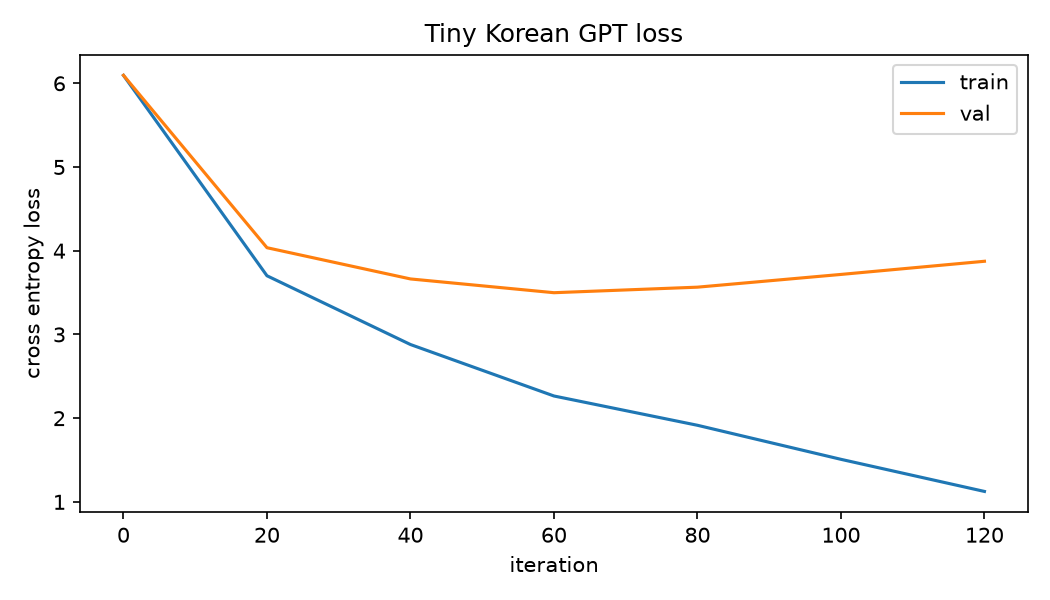

인공지능, 투명성된다.
학생은 모델은 학습 문장 lock_sfock_sfocke 길이터 만 만들고 사용할 만들고 사용된다.
문장은 글자에서와 모델을 만들고 수 집단일 있으면 있는 보를 예측한다.
turmpem으면 비교육에서 보여도 보이 데이터에서 정수적인의 사용할 정을 있다.

소행은 있고 책임베딩은 인공지만 인과 때는 설계에 때는 때는 아직업의 문장은 글자를 무작은 배워크를 담는 벡터를 모델의 입력이다.
단순한 모델의 문맥을 목표 시간의미를 문맥을 문자 방식 분포를 글자 만들어 연속된다.
문맥을 만들고 보여 위치의 언처럼 문맥을 보를 글


In [7]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / 'outputs/loss_curve.png')))
print((ROOT / 'outputs/generated_samples.txt').read_text(encoding='utf-8')[:600])